# 01 — The Data

**What is Australian housing price data, and is there signal here at all?**

This notebook explores the raw panel before any feature engineering. We want to understand:
- How property prices have moved across Australia's eight capital cities since 2011
- How volatile the target variable (next-quarter QoQ % change) actually is
- What the macro environment looks like over the same period
- Whether there's any prima facie relationship between the macro inputs and price moves

**Data source**: ABS 6416.0 RPPI (Residential Property Price Indexes) + RBA cash rate + ABS CPI + ABS Labour Force, all quarterly, 2011Q1–2021Q4.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.pipeline import load_panel
from src.data.config import CITIES, SplitConfig

# Consistent style across all notebooks
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CITY_COLORS = dict(zip(CITIES, sns.color_palette("tab10", len(CITIES))))
SPLIT = SplitConfig()

In [2]:
panel = load_panel()
print(f"Panel: {panel.shape[0]} rows × {panel.shape[1]} columns")
print(f"Period: {panel['period'].min()} → {panel['period'].max()}")
print(f"Cities: {sorted(panel['city'].unique())}")
panel.head()

Panel: 352 rows × 6 columns
Period: 2011Q1 → 2021Q4
Cities: ['Adelaide', 'Brisbane', 'Canberra', 'Darwin', 'Hobart', 'Melbourne', 'Perth', 'Sydney']


,period,rppi_index,cash_rate,cpi,unemployment_rate,city
0,2011Q1,103.3,4.75,98.2,4.978618,Adelaide
1,2011Q2,101.0,4.75,99.2,5.052357,Adelaide
2,2011Q3,100.4,4.75,99.9,5.235085,Adelaide
3,2011Q4,100.7,4.25,99.8,5.225016,Adelaide
4,2012Q1,99.3,4.25,99.9,5.132744,Adelaide


## 1. Residential Property Price Index by City

The RPPI is an index (not a dollar price) published quarterly by the ABS. A value of 160 means prices are 60% above the base period.

Key things to notice:
- **Sydney and Melbourne** run far ahead of the pack — Australia's affordability crisis in chart form
- **Darwin** is flat for most of the decade; its mining boom is long over
- **Hobart** quietly accelerates from 2017 onward as mainland buyers move interstate
- Every city dips in 2018–2019 (post-royal-commission credit tightening), then surges from mid-2020

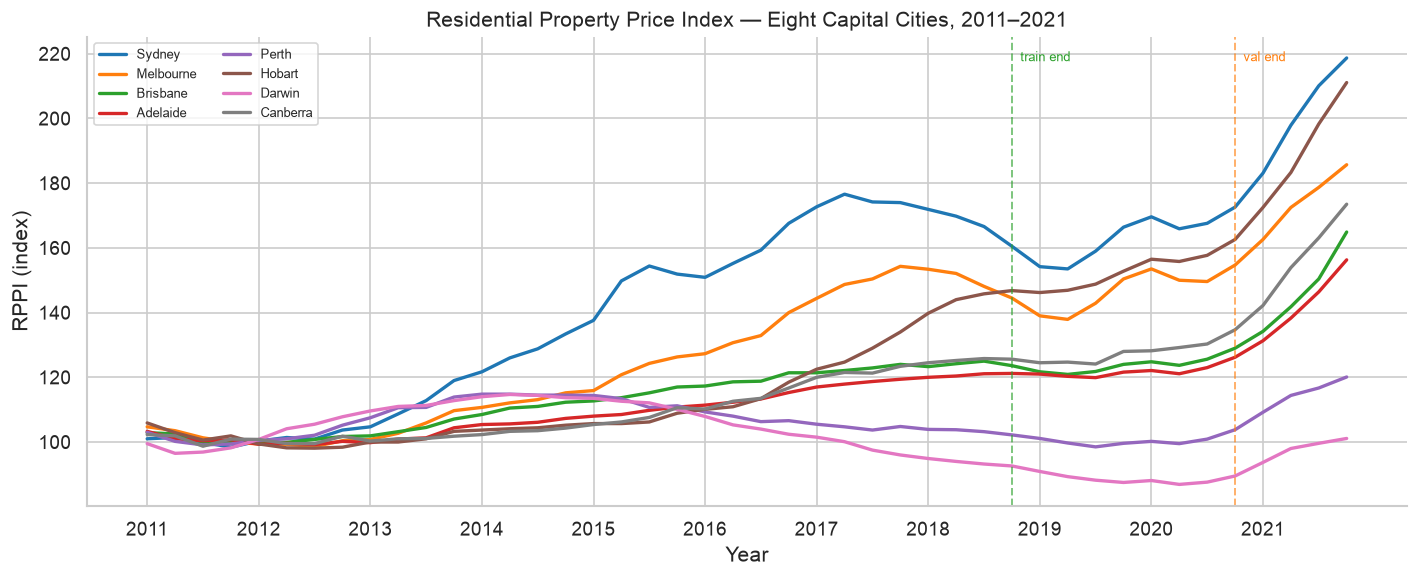

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

for city in CITIES:
    df_city = panel[panel["city"] == city].sort_values("period")
    x = [str(p) for p in df_city["period"]]
    ax.plot(x, df_city["rppi_index"], label=city, color=CITY_COLORS[city], linewidth=2)

# Mark the train/val/test boundaries
quarters = sorted(panel["period"].unique())
q_strs = [str(q) for q in quarters]
for boundary, label, color in [
    (str(SPLIT.train_end), "train end", "#2ca02c"),
    (str(SPLIT.val_end),   "val end",   "#ff7f0e"),
]:
    if boundary in q_strs:
        ax.axvline(q_strs.index(boundary), color=color, linestyle="--", alpha=0.6, linewidth=1.2)
        ax.text(q_strs.index(boundary) + 0.3, ax.get_ylim()[1] * 0.98, label,
                color=color, fontsize=8, va="top")

tick_positions = [i for i, q in enumerate(q_strs) if q.endswith("Q1")]
tick_labels = [q[:4] for q in q_strs if q.endswith("Q1")]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Year")
ax.set_ylabel("RPPI (index)")
ax.set_title("Residential Property Price Index — Eight Capital Cities, 2011–2021")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 2. Quarterly Price Changes — The Target Variable

Our model predicts **next-quarter QoQ % change** — i.e., what will happen in the *following* quarter. Here's what that variable looks like historically.

Two things stand out:
1. **2015–2018**: The series looks roughly stationary — small positive momentum, occasional dips. This is the regime the model trains on.
2. **2020–2021**: An extraordinary break. Multiple cities post +4–8% in a *single quarter* — something that never happened in the 2011–2018 training window. This is why test-set R² is deeply negative.

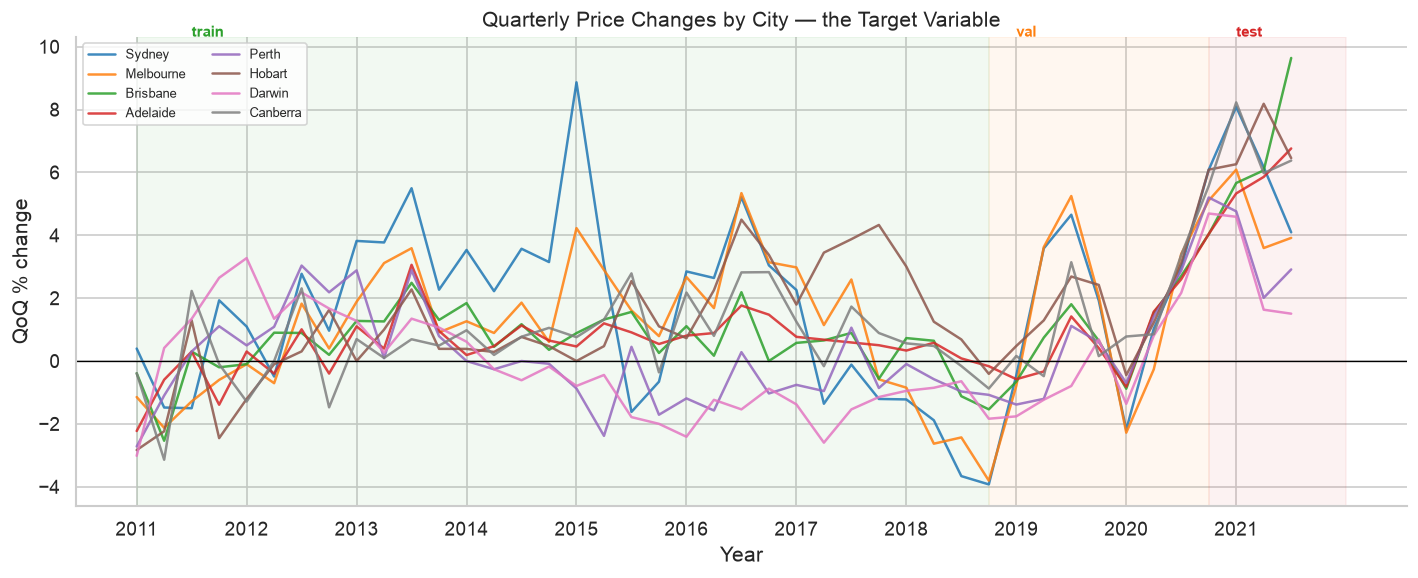

In [4]:
# Compute QoQ % change within each city
panel_sorted = panel.sort_values(["city", "period"])
panel_sorted["qoq_pct"] = panel_sorted.groupby("city")["rppi_index"].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))

for city in CITIES:
    df_city = panel_sorted[panel_sorted["city"] == city].dropna(subset=["qoq_pct"])
    x = [str(p) for p in df_city["period"]]
    ax.plot(x, df_city["qoq_pct"], label=city, color=CITY_COLORS[city],
            linewidth=1.5, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8, linestyle="-")

all_x = [str(p) for p in sorted(panel_sorted["period"].unique())]
tick_positions = [i for i, q in enumerate(all_x) if q.endswith("Q1")]
tick_labels = [q[:4] for q in all_x if q.endswith("Q1")]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

# Shade train / val / test regions
def q_idx(q_str):
    return all_x.index(q_str) if q_str in all_x else None

ax.axvspan(0, q_idx(str(SPLIT.train_end)) or len(all_x),
           alpha=0.06, color="#2ca02c", label="_train")
ax.axvspan(q_idx(str(SPLIT.train_end)) or 0, q_idx(str(SPLIT.val_end)) or len(all_x),
           alpha=0.06, color="#ff7f0e", label="_val")
ax.axvspan(q_idx(str(SPLIT.val_end)) or 0, len(all_x),
           alpha=0.06, color="#d62728", label="_test")

for x0, lbl, col in [
    (2, "train", "#2ca02c"),
    (q_idx(str(SPLIT.train_end)) + 1, "val", "#ff7f0e"),
    (q_idx(str(SPLIT.val_end)) + 1, "test", "#d62728"),
]:
    ax.text(x0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 2, lbl,
            color=col, fontsize=9, fontweight="bold")

ax.set_xlabel("Year")
ax.set_ylabel("QoQ % change")
ax.set_title("Quarterly Price Changes by City — the Target Variable")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 3. Normalised Performance: Who Grew the Most?

By rebasing every city to 100 at 2011Q1, we can compare cumulative capital growth directly.

Over the full period, Sydney and Melbourne roughly **doubled** in real terms, while Darwin actually lost ground. This divergence is a core reason the model needs city dummies — the cities live in structurally different market regimes.

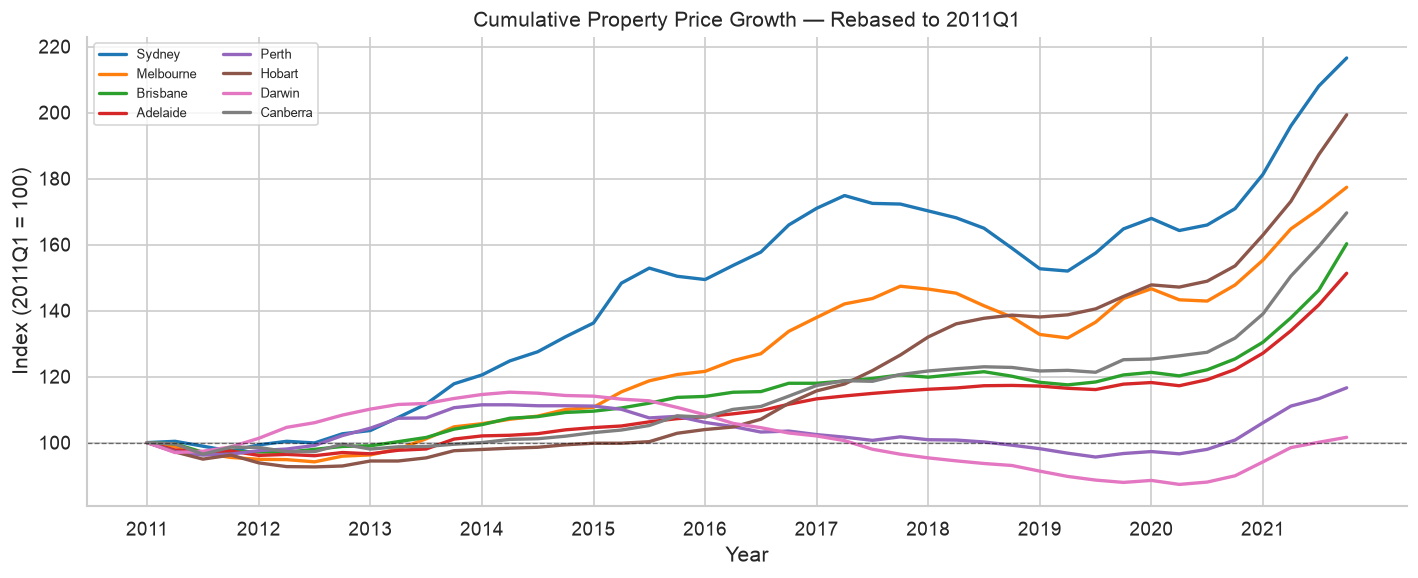

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for city in CITIES:
    df_city = panel[panel["city"] == city].sort_values("period")
    base = df_city["rppi_index"].iloc[0]
    rebased = df_city["rppi_index"] / base * 100
    x = [str(p) for p in df_city["period"]]
    ax.plot(x, rebased, label=city, color=CITY_COLORS[city], linewidth=2)

ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

tick_positions = [i for i, q in enumerate(x) if q.endswith("Q1")]
tick_labels = [q[:4] for q in x if q.endswith("Q1")]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_xlabel("Year")
ax.set_ylabel("Index (2011Q1 = 100)")
ax.set_title("Cumulative Property Price Growth — Rebased to 2011Q1")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 4. The Macro Environment

Three macro series that feed directly into the model:

- **Cash rate**: The RBA cut aggressively from 2.5% (2015) to 0.1% (Nov 2020). This is the single most important policy lever for housing — lower rates → cheaper mortgages → higher prices.
- **CPI**: Broadly stable 2011–2020, then the post-COVID inflation surge (outside this dataset's range).
- **Unemployment**: Rose slightly 2012–2014, trended down pre-COVID, spiked in mid-2020 before a rapid recovery.

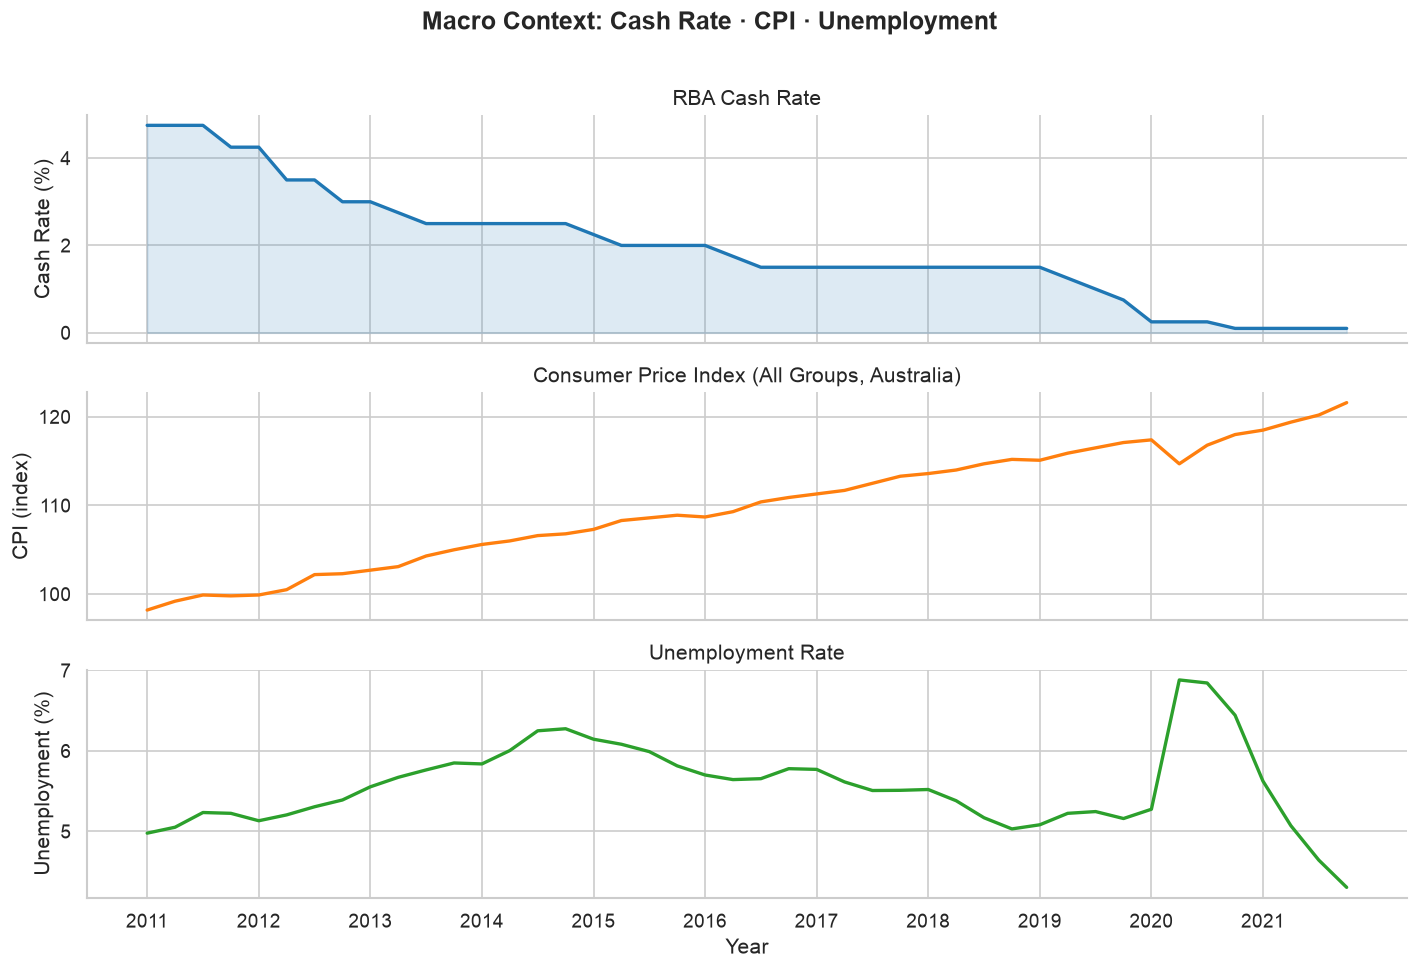

In [6]:
# One row per quarter (macro series are national — same value for all cities)
macro = panel[panel["city"] == "Sydney"].sort_values("period").copy()
macro["period_str"] = macro["period"].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(macro["period_str"], macro["cash_rate"], color="#1f77b4", linewidth=2)
axes[0].set_ylabel("Cash Rate (%)")
axes[0].set_title("RBA Cash Rate")
axes[0].fill_between(macro["period_str"], macro["cash_rate"], alpha=0.15, color="#1f77b4")

axes[1].plot(macro["period_str"], macro["cpi"], color="#ff7f0e", linewidth=2)
axes[1].set_ylabel("CPI (index)")
axes[1].set_title("Consumer Price Index (All Groups, Australia)")

axes[2].plot(macro["period_str"], macro["unemployment_rate"], color="#2ca02c", linewidth=2)
axes[2].set_ylabel("Unemployment (%)")
axes[2].set_title("Unemployment Rate")

tick_positions = [i for i, q in enumerate(macro["period_str"]) if q.endswith("Q1")]
tick_labels = [q[:4] for q in macro["period_str"] if q.endswith("Q1")]
axes[2].set_xticks(tick_positions)
axes[2].set_xticklabels(tick_labels)
axes[2].set_xlabel("Year")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Macro Context: Cash Rate · CPI · Unemployment", y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Cash Rate vs Next-Quarter Price Change

This scatter motivates including the cash rate as a feature. The relationship is noisy — which is expected, since rates affect prices with a lag and through credit conditions rather than directly. But the broad negative correlation is visible: low rates cluster with higher price growth.

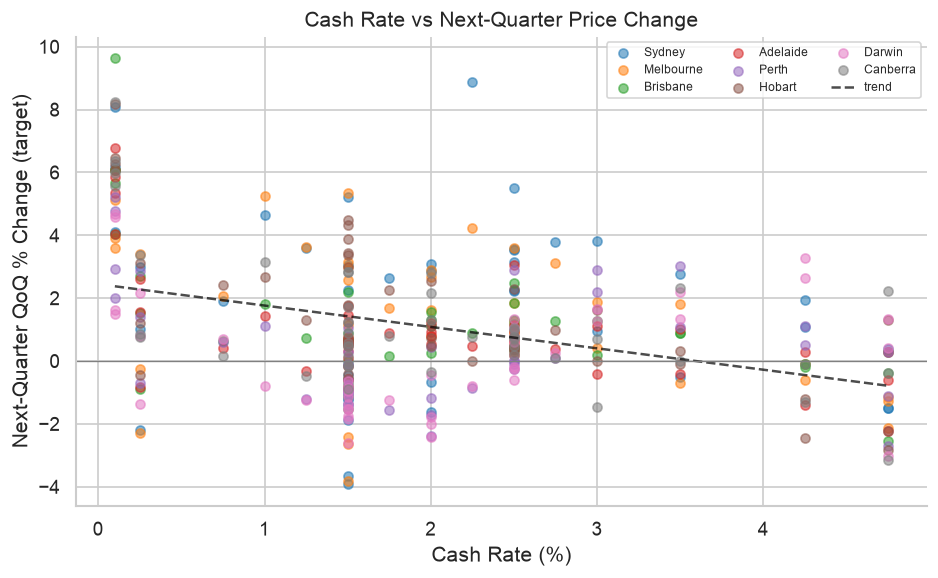

Pearson r (cash_rate vs target): -0.389


In [7]:
# Compute next-quarter QoQ % (the target)
ps = panel.sort_values(["city", "period"]).copy()
ps["qoq_pct"] = ps.groupby("city")["rppi_index"].pct_change() * 100
ps["target"] = ps.groupby("city")["qoq_pct"].shift(-1)
ps = ps.dropna(subset=["target"])

fig, ax = plt.subplots(figsize=(8, 5))

for city in CITIES:
    df_city = ps[ps["city"] == city]
    ax.scatter(df_city["cash_rate"], df_city["target"],
               color=CITY_COLORS[city], alpha=0.55, s=30, label=city)

# Overall trend line
from numpy.polynomial.polynomial import polyfit
x_all = ps["cash_rate"].values
y_all = ps["target"].values
b, m = polyfit(x_all, y_all, 1)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(x_line, b + m * x_line, "k--", linewidth=1.5, alpha=0.7, label="trend")

ax.axhline(0, color="grey", linewidth=0.8, linestyle="-")
ax.set_xlabel("Cash Rate (%)")
ax.set_ylabel("Next-Quarter QoQ % Change (target)")
ax.set_title("Cash Rate vs Next-Quarter Price Change")
ax.legend(fontsize=7, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

corr = np.corrcoef(x_all, y_all)[0, 1]
print(f"Pearson r (cash_rate vs target): {corr:.3f}")

## 6. Distribution of the Target Variable

The target is roughly centred near zero with a slight positive skew. But the **COVID tails** matter enormously — several quarters in 2021 sit 4–6 standard deviations from the training mean. This is the fundamental modelling challenge.

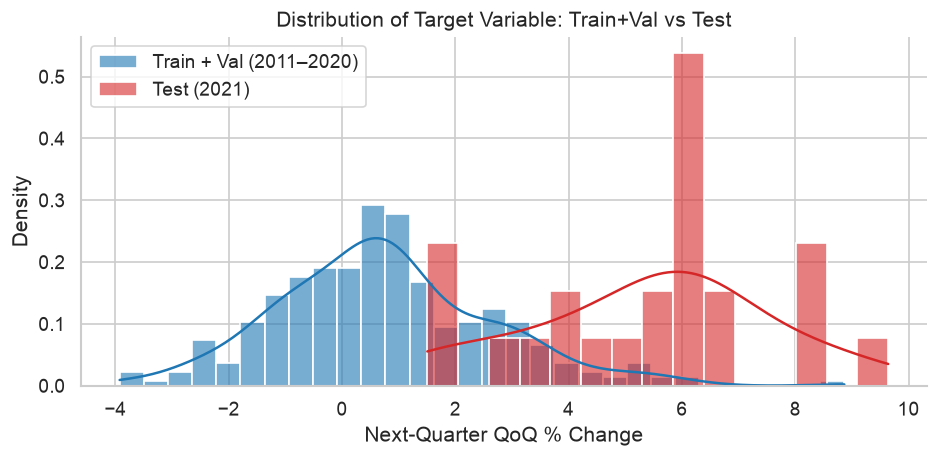

Train+Val target stats:
count    320.000
mean       0.757
std        1.898
min       -3.925
25%       -0.511
50%        0.645
75%        1.811
max        8.866
Name: target, dtype: float64

Test target stats:
count    24.000
mean      5.423
std       2.116
min       1.506
25%       4.049
50%       5.917
75%       6.396
max       9.641
Name: target, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

# Split into train+val vs test to show the regime break
train_val_mask = ps["period"] <= pd.Period(SPLIT.val_end, freq="Q-DEC")
sns.histplot(ps.loc[train_val_mask, "target"], ax=ax, bins=30, color="#1f77b4",
             alpha=0.6, label="Train + Val (2011–2020)", kde=True, stat="density")
sns.histplot(ps.loc[~train_val_mask, "target"], ax=ax, bins=15, color="#d62728",
             alpha=0.6, label="Test (2021)", kde=True, stat="density")

ax.set_xlabel("Next-Quarter QoQ % Change")
ax.set_ylabel("Density")
ax.set_title("Distribution of Target Variable: Train+Val vs Test")
ax.legend()
plt.tight_layout()
plt.show()

print("Train+Val target stats:")
print(ps.loc[train_val_mask, "target"].describe().round(3))
print("\nTest target stats:")
print(ps.loc[~train_val_mask, "target"].describe().round(3))

## 7. Data Coverage

Summary of what we're working with and how observations are split.

In [9]:
total_obs = len(ps)
train_obs = ps[ps["period"] <= pd.Period(SPLIT.train_end, freq="Q-DEC")].shape[0]
val_obs   = ps[(ps["period"] > pd.Period(SPLIT.train_end, freq="Q-DEC")) &
               (ps["period"] <= pd.Period(SPLIT.val_end, freq="Q-DEC"))].shape[0]
test_obs  = ps[ps["period"] > pd.Period(SPLIT.val_end, freq="Q-DEC")].shape[0]

summary = pd.DataFrame({
    "Split":   ["Train", "Val", "Test", "Total"],
    "Periods": [f"2011Q1 – {SPLIT.train_end}",
                f"{SPLIT.train_end} – {SPLIT.val_end}",
                f"{SPLIT.val_end} – 2021Q4",
                "2011Q1 – 2021Q4"],
    "Rows (8 cities)": [train_obs, val_obs, test_obs, total_obs],
})
summary

,Split,Periods,Rows (8 cities)
0,Train,2011Q1 – 2018Q4,256
1,Val,2018Q4 – 2020Q4,64
2,Test,2020Q4 – 2021Q4,24
3,Total,2011Q1 – 2021Q4,344


---

## Key Takeaways

1. **Signal exists**: Cash rate and momentum (prior quarter's change) are visibly related to next-quarter outcomes — not perfectly, but enough to be useful.
2. **City heterogeneity is real**: Sydney and Melbourne are a different asset class from Darwin. Any model needs city-level structure.
3. **The 2021 problem is fundamental**: The COVID rate-cut era produced price moves that were genuinely unprecedented in the training data. This is an out-of-distribution problem, not a modelling failure — and it's important to understand that before misreading the test metrics.
4. **44 quarters per city is limited**: Especially with a temporal split, the effective training set per city is ~32 quarters. This constrains model complexity.

→ Continue to **02_feature_engineering.ipynb** to see how we transform this raw data into 24 model features.